In [1]:
import json

with open("fit_values.json", "r") as f:
    values = json.load(f)


with open("fit_errors.json", "r") as f:
    errors = json.load(f)

#Siamo riusciti a passare i dati dei fit al file json, ora possiamo usarli per fare i grafici.

#Interpoliamo le norme

masse=[25, 50, 75, 100, 125, 150, 175, 200]
fit_MH_values=values
fit_MH_errors=errors

print(fit_MH_values)
print(fit_MH_errors)    


{'MH25': {'norm': 0.682020534094887, 'mu': 24.4948584181444, 'sigma': 2.9947645616897876, 'gamma': 0.20662519986136063, 'norm2': 0.3077370942677364, 'mu2': 27.176364848190314, 'sigma2': 1.6981769202210721, 'gamma2': 0.001}, 'MH50': {'norm': 0.5570171666241786, 'mu': 51.789847578340705, 'sigma': 5.505738056673616, 'gamma': 1.7833280320442622, 'norm2': 0.5550792018084296, 'mu2': 50.41249139360733, 'sigma2': 0.5867923616018343, 'gamma2': 0.001}, 'MH75': {'norm': 0.6444701712721482, 'mu': 74.71803096180155, 'sigma': 8.198288025790674, 'gamma': 2.866367690311915, 'norm2': 0.3688330898017668, 'mu2': 77.95596907321944, 'sigma2': 4.85294864422987, 'gamma2': 0.001}, 'MH100': {'norm': 0.7667105898426677, 'mu': 103.41498730415057, 'sigma': 5.707662064168594, 'gamma': 3.1695488679939436, 'norm2': 0.26287455944987237, 'mu2': 95.46191785407376, 'sigma2': 13.796789530506208, 'gamma2': 0.001}, 'MH125': {'norm': 0.8038537357395943, 'mu': 128.51644446218845, 'sigma': 7.022601274757489, 'gamma': 4.363073

In [2]:
# Estraggo tutti i 'norm' iterando sui valori del dizionario principale
norms = [fit["norm"] for fit in fit_MH_values.values()]
norms_errors = [fit["norm"] for fit in fit_MH_errors.values()]
norms_2 = [fit["norm2"] for fit in fit_MH_values.values()]
norms_2_errors = [fit["norm2"] for fit in fit_MH_errors.values()]

print(norms)
print(norms_errors)
print(norms_2)
print(norms_2_errors)


[0.682020534094887, 0.5570171666241786, 0.6444701712721482, 0.7667105898426677, 0.8038537357395943, 0.7003234700431133, 0.7587725225890556, 0.6598718712321834]
[0.014517856701713962, 0.0038244086675260436, 0.019080083722452252, 0.019246456510648685, 0.029344769975457027, 0.0444826193075926, 0.022584262140787206, 0.04388675259964073]
[0.3077370942677364, 0.5550792018084296, 0.3688330898017668, 0.26287455944987237, 0.2412683523141502, 0.3454107575352435, 0.2591955442638899, 0.3631236498233513]
[0.014245516920382425, 0.06660698434396901, 0.018806214568614463, 0.01792439027204349, 0.027493080096113155, 0.03834500489781809, 0.021010980272228273, 0.04131141034139166]


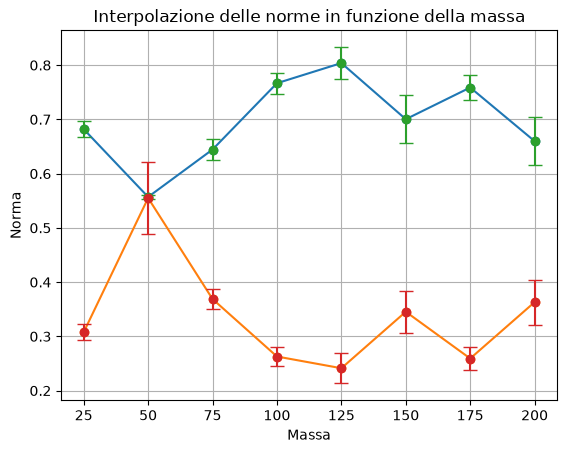

In [3]:
#Facciamo la prima interpolazione, dopo vedremo come aggiungere gli erri 
from scipy.interpolate import interp1d
from matplotlib import pyplot as plt
import numpy as np

fig=plt.figure()

plt.plot(masse, norms, marker='o')
plt.plot(masse, norms_2, marker='o')
plt.xlabel("Massa")
plt.errorbar(masse, norms, yerr=norms_errors, fmt='o', capsize=5)
plt.errorbar(masse, norms_2, yerr=norms_2_errors, fmt='o', capsize=5)
plt.ylabel("Norma")
plt.title("Interpolazione delle norme in funzione della massa")
plt.grid()
plt.show()  

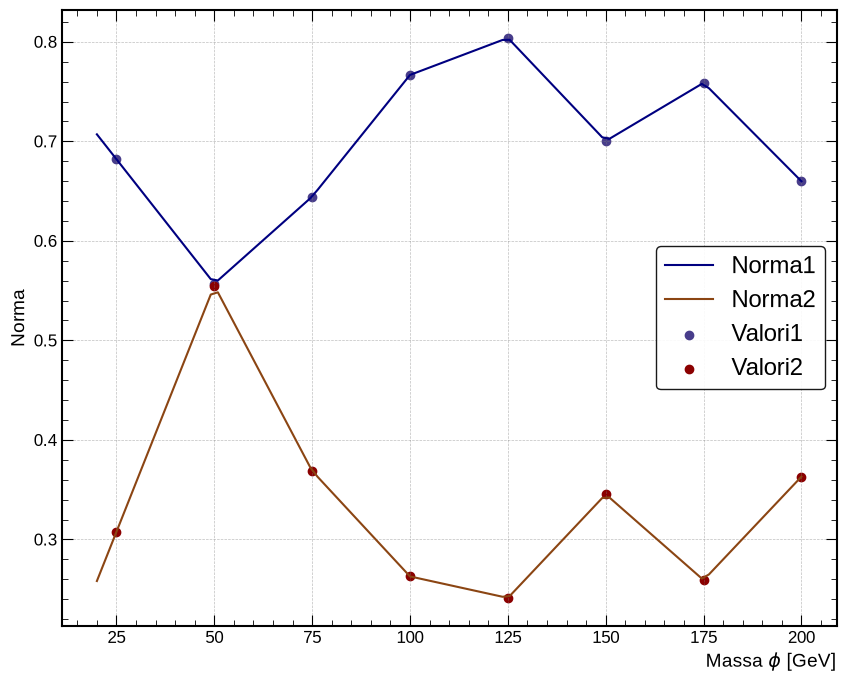

In [4]:
#Interpoliamo le norme e disegnamo la funzione
from matplotlib.ticker import AutoMinorLocator
norms_interpolation = interp1d(masse, norms, kind='linear', fill_value='extrapolate')
norms_2_interpolation = interp1d(masse, norms_2, kind='linear', fill_value='extrapolate')

#Disegnamo la funzione interpolata su un range di masse più ampio
mass_range = np.linspace(20, 200, 100)  # Range di masse
norm_interpolated = norms_interpolation(mass_range)  
norm_2_interpolated = norms_2_interpolation(mass_range)  

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})

fig, ax= plt.subplots(figsize=(10,8))
plt.plot(mass_range, norm_interpolated, label='Norma1', color='navy')
plt.plot(mass_range, norm_2_interpolated, label='Norma2', color='saddlebrown')
plt.scatter(masse, norms, color='darkslateblue', label='Valori1')
plt.scatter(masse, norms_2, color='darkred', label='Valori2')
plt.xlabel(r"Massa $\phi$ [GeV]", fontsize=14, loc="right")
plt.ylabel("Norma", fontsize=14)
plt.title("")
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend( fontsize=17, frameon=True, edgecolor="black", facecolor="white", framealpha=0.9)
plt.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Interpolazione_Norme.png', bbox_inches='tight')
plt.show()



[24.4948584181444, 51.789847578340705, 74.71803096180155, 103.41498730415057, 128.51644446218845, 154.44907205736789, 180.06642923175443, 206.15757663467727]
[0.0492763335929407, 0.04584217566701909, 0.12179740268040007, 0.08617069306048109, 0.12790351029925837, 0.14958046399544855, 0.14395644867929036, 0.1889831232922461]
[27.176364848190314, 50.41249139360733, 77.95596907321944, 95.46191785407376, 118.22711708564648, 144.24597939717438, 161.80254028980946, 185.88177352240427]
[0.0474420613999034, 0.00734987539934505, 0.08934072117532924, 0.5521819173258976, 1.1399679384013741, 1.1022375702654739, 1.3766950374844793, 2.015982913305664]


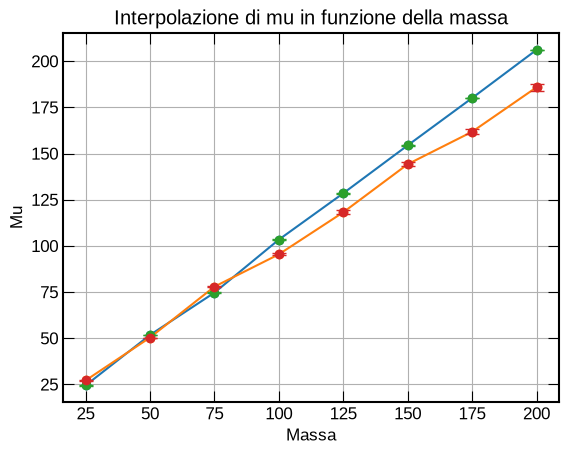

In [5]:
mu=[fit["mu"] for fit in fit_MH_values.values()]
mu_errors=[fit["mu"] for fit in fit_MH_errors.values()]
mu_2=[fit["mu2"] for fit in fit_MH_values.values()]
mu_2_errors=[fit["mu2"] for fit in fit_MH_errors.values()]

print(mu)
print(mu_errors)
print(mu_2)
print(mu_2_errors)

fig=plt.figure()
plt.plot(masse, mu, marker='o')
plt.plot(masse, mu_2, marker='o')
plt.xlabel("Massa")
plt.errorbar(masse, mu, yerr=mu_errors, fmt='o', capsize=5)
plt.errorbar(masse, mu_2, yerr=mu_2_errors, fmt='o', capsize=5)
plt.ylabel("Mu")
plt.title("Interpolazione di mu in funzione della massa")
plt.grid()
plt.show()  




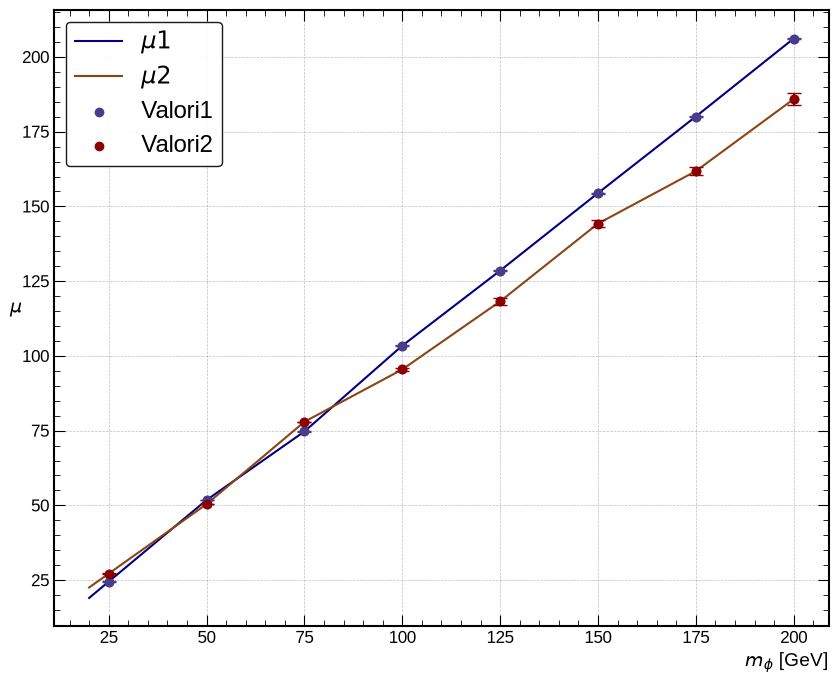

In [6]:
from scipy.interpolate import interp1d

mu_interpolation = interp1d(masse, mu, kind='linear', fill_value='extrapolate')
mu_2_interpolation = interp1d(masse, mu_2, kind='linear', fill_value='extrapolate')

mass_range = np.linspace(20, 200, 100)  # Range di masse
mu_interpolated = mu_interpolation(mass_range)
mu_2_interpolated = mu_2_interpolation(mass_range)

#Ricopiamo le impostazioni del grafico precednte e vi inseriamo i valori giusti

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})

fig, ax= plt.subplots(figsize=(10,8))
plt.plot(mass_range, mu_interpolated, label=r'$\mu1$', color='navy')
plt.plot(mass_range, mu_2_interpolated, label=r"$\mu2$", color='saddlebrown')
plt.errorbar(masse, mu, color="darkslateblue" , yerr=mu_errors, fmt='o', capsize=5)
plt.errorbar(masse, mu_2, color="darkred", yerr=mu_2_errors, fmt='o', capsize=5)
plt.scatter(masse, mu, color='darkslateblue', label='Valori1')
plt.scatter(masse, mu_2, color='darkred', label='Valori2')
plt.xlabel(r"$m_{\phi}$ [GeV]", fontsize=14, loc="right")
plt.ylabel(r"$\mu$", fontsize=14, rotation=0)
plt.title("")
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend( fontsize=17, frameon=True, edgecolor="black", facecolor="white", framealpha=0.9)
plt.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Interpolazione_Mu.png', bbox_inches='tight')
plt.show()



[0.0492763335929407, 0.04584217566701909, 0.12179740268040007, 0.08617069306048109, 0.12790351029925837, 0.14958046399544855, 0.14395644867929036, 0.1889831232922461]
[0.0474420613999034, 0.00734987539934505, 0.08934072117532924, 0.5521819173258976, 1.1399679384013741, 1.1022375702654739, 1.3766950374844793, 2.015982913305664]


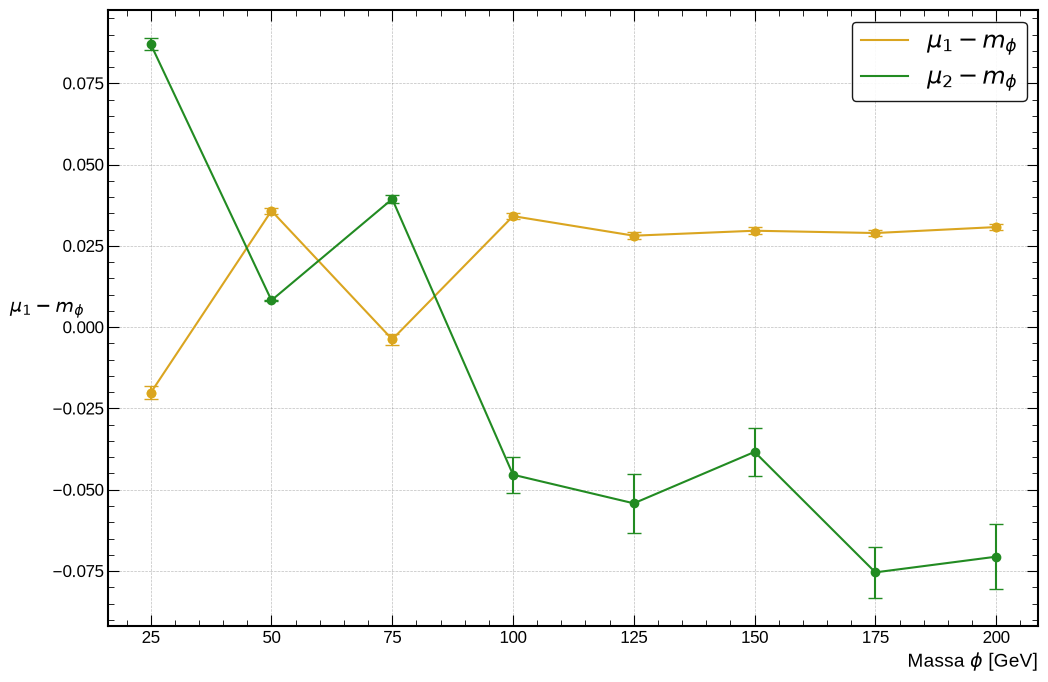

In [7]:
#Bias o Plot Fu

fig, ax= plt.subplots(figsize=(12,8))

bias1=[(u-m)/m for u, m in zip(mu, masse) ]
bias2=[(u-m)/m for u, m in zip(mu_2, masse,)]

errore_scarto=[errore/m for errore, m  in zip(mu_errors, masse)]
errore_2_scarto=[errore/m for errore, m  in zip(mu_2_errors, masse)]

plt.scatter(masse, bias1, color='gold')
plt.plot(masse, bias1, label=r'$\mu_1-m_{\phi}$', color='goldenrod')
plt.plot(masse, bias2, label=r'$\mu_2-m_{\phi}$', color='forestgreen')
plt.errorbar(masse, bias1, color="goldenrod" , yerr=errore_scarto, fmt='o', capsize=5)
plt.errorbar(masse, bias2,color='forestgreen', yerr=errore_2_scarto, fmt='o', capsize=5 )
plt.xlabel(r"Massa $\phi$ [GeV]", fontsize=14, loc="right")
plt.ylabel(r"$\mu_1-m_{\phi}$", fontsize=14, rotation=0)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend( fontsize=17, frameon=True, edgecolor="black", facecolor="white", framealpha=0.9)
plt.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
#plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Interpolazione_Mu.png', bbox_inches='tight')
print(mu_errors)
print(mu_2_errors)
plt.show()

/tmp/ipykernel_42326/3688994475.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


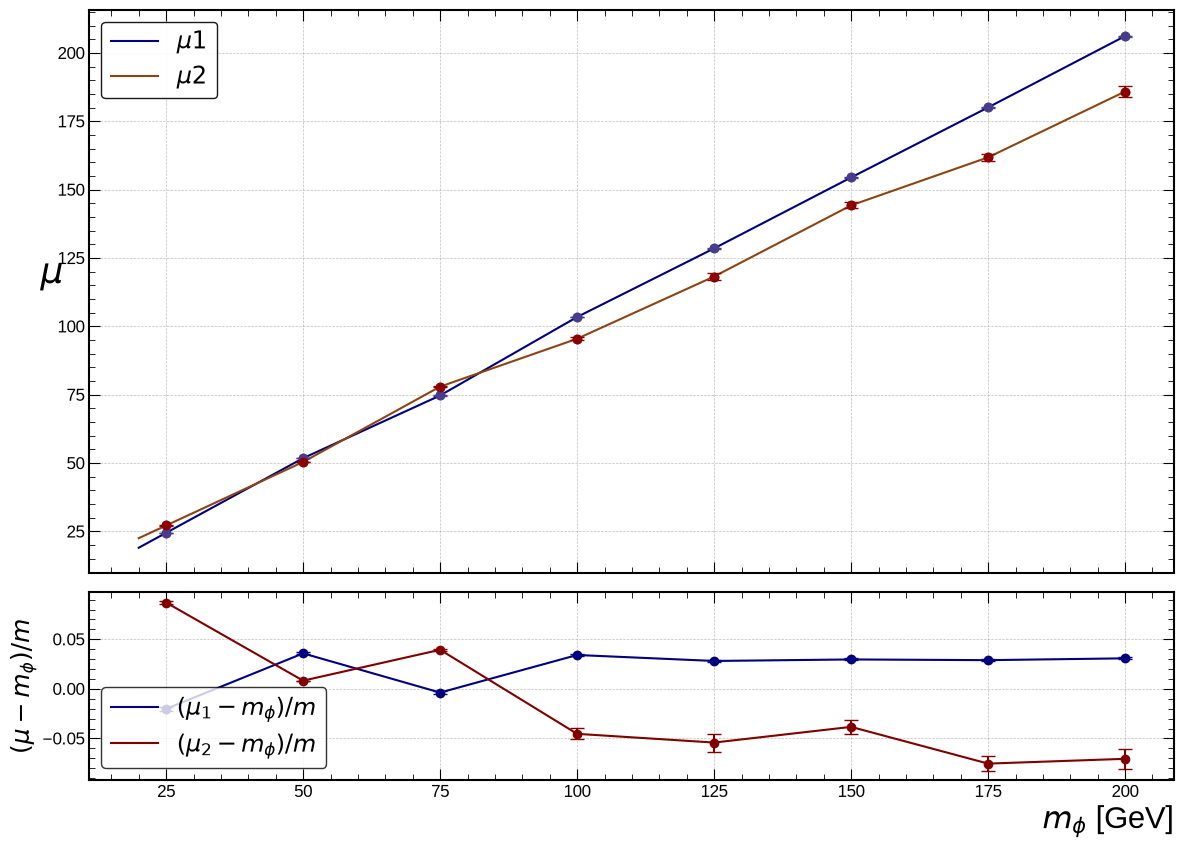

In [18]:
#Proviamo col Plot FU
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Dejavu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
    'text.usetex': False, # Setta a True se hai un'installazione LaTeX funzionante
})

#CONFIGURAIMO IL GRAFICO 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

#Grafico principale
ax1.plot(mass_range, mu_interpolated, label=r'$\mu1$', color='navy')
ax1.plot(mass_range, mu_2_interpolated, label=r"$\mu2$", color='saddlebrown')
ax1.errorbar(masse, mu, color="darkslateblue" , yerr=mu_errors, fmt='o', capsize=5)
ax1.errorbar(masse, mu_2, color="darkred", yerr=mu_2_errors, fmt='o', capsize=5)
ax1.scatter(masse, mu, color='darkslateblue', label=None)
ax1.scatter(masse, mu_2, color='darkred', label=None)
ax2.set_xlabel(r"$m_{\phi}$ [GeV]", fontsize=22, loc="right")
ax1.set_ylabel(r"$\mu$", fontsize=26, rotation=0)
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.legend( fontsize=17, frameon=True, edgecolor="black", facecolor="white", framealpha=0.9)
ax1.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
#plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Interpolazione_Mu.png', bbox_inches='tight')
ax2.scatter(masse, bias1, color='gold')
ax2.plot(masse, bias1, label=r'$(\mu_1-m_{\phi})/m$', color='navy')
ax2.plot(masse, bias2, label=r'$(\mu_2-m_{\phi})/m$', color='maroon')
ax2.errorbar(masse, bias1, color="navy" , yerr=errore_scarto, fmt='o', capsize=5)
ax2.errorbar(masse, bias2,color='maroon', yerr=errore_2_scarto, fmt='o', capsize=5 )
ax2.set_ylabel(r"$(\mu-m_{\phi})/m$", fontsize=18, rotation=90)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.legend( fontsize=17, frameon=True, edgecolor="black", facecolor="white", framealpha=0.8)
ax2.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Plot_Fu.png', bbox_inches='tight')
plt.show()


#Secondo grafico



[2.9947645616897876, 5.505738056673616, 8.198288025790674, 5.707662064168594, 7.022601274757489, 7.829211636343578, 11.145471247451864, 11.060971290392189]
[0.024183142182699013, 0.06439548050787058, 0.14706235678016633, 0.151025955672202, 0.23603175659003633, 0.2855149338668941, 0.2035556828492453, 0.20785719468824482]
[1.6981769202210721, 0.5867923616018343, 4.85294864422987, 13.796789530506208, 15.369404681132965, 19.2793459973479, 23.5492147874244, 20.43678384178792]
[0.037821387871113665, 0.03882543884848561, 0.11259480529875948, 0.3129291580889273, 0.4857105585011012, 0.5840626731686642, 0.581549419554561, 0.8860612922558208]


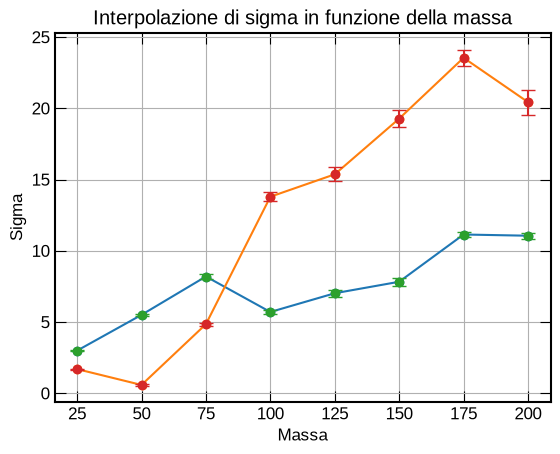

In [9]:
#Ora le sigma

sigma=[fit["sigma"] for fit in fit_MH_values.values()]
sigma_errors=[fit["sigma"] for fit in fit_MH_errors.values()]   
sigma_2=[fit["sigma2"] for fit in fit_MH_values.values()]
sigma_2_errors=[fit["sigma2"] for fit in fit_MH_errors.values()]

print(sigma)
print(sigma_errors)
print(sigma_2)
print(sigma_2_errors)

fig=plt.figure()
plt.plot(masse, sigma, marker='o')
plt.plot(masse, sigma_2, marker='o')
plt.xlabel("Massa")
plt.errorbar(masse, sigma, yerr=sigma_errors, fmt='o', capsize=5)
plt.errorbar(masse, sigma_2, yerr=sigma_2_errors, fmt='o', capsize=5)
plt.ylabel("Sigma")
plt.title("Interpolazione di sigma in funzione della massa")
plt.grid()
plt.show()

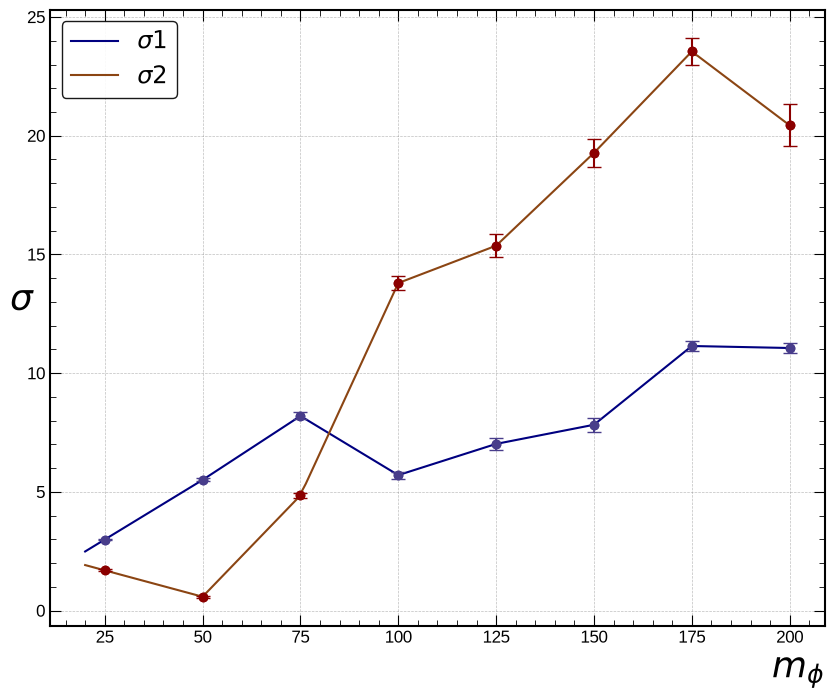

In [19]:
#Ora interpoliamo le sigma

sigma_interpolation = interp1d(masse, sigma, kind='linear', fill_value='extrapolate')
sigma_2_interpolation = interp1d(masse, sigma_2, kind='linear', fill_value='extrapolate')   

sigma_interpolated = sigma_interpolation(mass_range)
sigma_2_interpolated = sigma_2_interpolation(mass_range)    

#Ricopiamo le impostazioni del grafico precednte e vi inseriamo i valori giusti

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})

fig, ax= plt.subplots(figsize=(10,8))
plt.plot(mass_range, sigma_interpolated, label=r'$\sigma1$', color='navy')
plt.plot(mass_range, sigma_2_interpolated, label=r'$\sigma2$', color='saddlebrown')
plt.scatter(masse, sigma, color='darkslateblue')
plt.scatter(masse, sigma_2, color='darkred')
plt.errorbar(masse, sigma, color="darkslateblue" , yerr=sigma_errors, fmt='o', capsize=5)
plt.errorbar(masse, sigma_2, color="darkred", yerr=sigma_2_errors, fmt='o', capsize=5)
plt.xlabel (r"$m_{\phi}$", fontsize=26, loc="right")
plt.ylabel(r"$\sigma$", fontsize=26, rotation=0)
plt.title("")
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc="upper left", fontsize=17, frameon=True, edgecolor="black", facecolor="white", framealpha=0.9)
plt.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Interpolazione_Sigma.png', bbox_inches='tight')
plt.show()

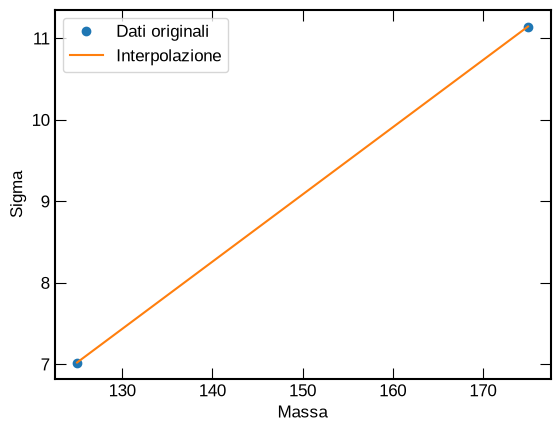

In [11]:
masse_prova = [125, 175]
sigma_prova=[sigma[4], sigma[6]]

sigma_interpolato_125_e_175=interp1d(masse_prova, sigma_prova, kind='linear', fill_value='extrapolate')

sigma_prova_interp=sigma_interpolato_125_e_175([125,150, 175])

plt.figure()
plt.plot(masse_prova, sigma_prova, 'o', label='Dati originali')
plt.plot([125, 150, 175], sigma_prova_interp, '-', label='Interpolazione')
plt.xlabel('Massa')
plt.ylabel('Sigma')
plt.legend()
plt.show()

[0.20662519986136063, 1.7833280320442622, 2.866367690311915, 3.1695488679939436, 4.363073523302437, 4.585004580556788, 2.904241183015285, 1.155194506556951]
[0.0113196536781634, 0.05304600281301752, 0.12092083767338035, 0.13973922523926996, 0.18924310917733367, 0.5434984229595639, 0.21859820810811437, 0.3639315022233919]
[0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]
[1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05]


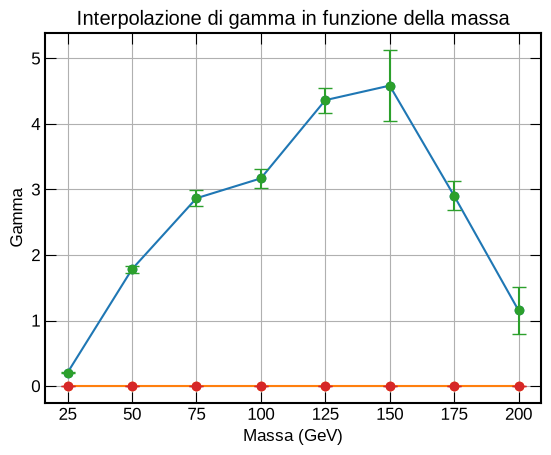

In [12]:
#Ora per le gamma

gamma=[fit["gamma"] for fit in fit_MH_values.values()]
gamma_errors=[fit["gamma"] for fit in fit_MH_errors.values()]     
gamma_2=[fit["gamma2"] for fit in fit_MH_values.values()]
gamma_2_errors=[fit["gamma2"] for fit in fit_MH_errors.values()]  

print(gamma)
print(gamma_errors)
print(gamma_2)
print(gamma_2_errors)

fig=plt.figure()
plt.plot(masse, gamma, marker='o')
plt.plot(masse, gamma_2, marker='o')
plt.xlabel("Massa (GeV)")
plt.errorbar(masse, gamma, yerr=gamma_errors, fmt='o', capsize=5)
plt.errorbar(masse, gamma_2, yerr=gamma_2_errors, fmt='o', capsize=5)
plt.ylabel("Gamma")
plt.title("Interpolazione di gamma in funzione della massa")
plt.grid()
plt.show()

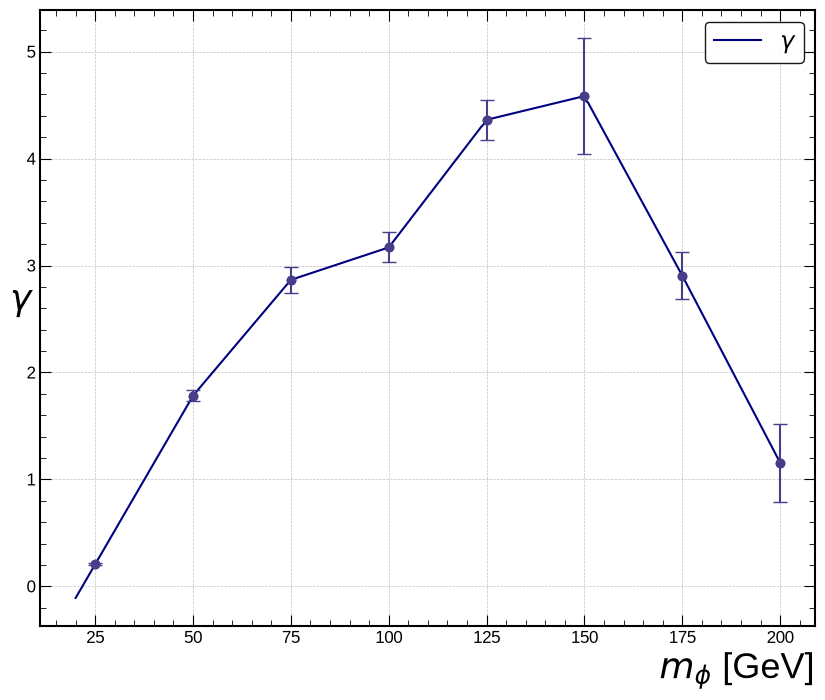

In [20]:
#Interpoliamo una sola gamma, l'alta è costanete


gamma_interpolation = interp1d(masse, gamma, kind='linear', fill_value='extrapolate')

gamma_interpolated = gamma_interpolation(mass_range)

#Ricopiamo le impostazioni del grafico precednte e vi inseriamo i valori giusti

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})

fig, ax= plt.subplots(figsize=(10,8))
plt.plot(mass_range, gamma_interpolated, label=r'$\gamma$', color='navy')
plt.scatter(masse, gamma, color='darkslateblue')
plt.errorbar(masse, gamma, color="darkslateblue" , yerr=gamma_errors, fmt='o', capsize=5)
plt.xlabel(r"$m_{\phi}$ [GeV]", fontsize=26, loc="right")
plt.ylabel(r"$\gamma$", fontsize=26, rotation=0)
plt.title("")
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(fontsize=17, frameon=True, edgecolor="black", facecolor="white", framealpha=0.9)
plt.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Interpolazione_Gamma.png', bbox_inches='tight')
plt.show()

In [14]:
#Fit per una massa non data

class DoubleVoigtFit:
    def __init__(self, mass, fit_values):
        self.mass = mass
        self.fit_values = fit_values

    def get_fit_parameters(self):
        # Interpoliamo i parametri per la massa specificata
        norm_interp = interp1d(masse, [fit["norm"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        norm2_interp = interp1d(masse, [fit["norm2"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        mu_interp = interp1d(masse, [fit["mu"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        mu2_interp = interp1d(masse, [fit["mu2"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        sigma_interp = interp1d(masse, [fit["sigma"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        sigma2_interp = interp1d(masse, [fit["sigma2"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        gamma_interp = interp1d(masse, [fit["gamma"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        gamma2_interp = interp1d(masse, [fit["gamma2"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')

        return {
            "norm": norm_interp(self.mass),
            "norm2": norm2_interp(self.mass),
            "mu": mu_interp(self.mass),
            "mu2": mu2_interp(self.mass),
            "sigma": sigma_interp(self.mass),
            "sigma2": sigma2_interp(self.mass),
            "gamma": gamma_interp(self.mass),
            "gamma2": gamma2_interp(self.mass)
        }

In [15]:
DoubleVoigtFit_80 = DoubleVoigtFit(80, fit_MH_values)

print(DoubleVoigtFit_80.get_fit_parameters())

fit_parameters_80 = DoubleVoigtFit_80.get_fit_parameters()



{'norm': array(0.66891825), 'norm2': array(0.34764138), 'mu': array(80.45742223), 'mu2': array(81.45715883), 'sigma': array(7.70016283), 'sigma2': array(6.64171682), 'gamma': array(2.92700393), 'gamma2': array(0.001)}


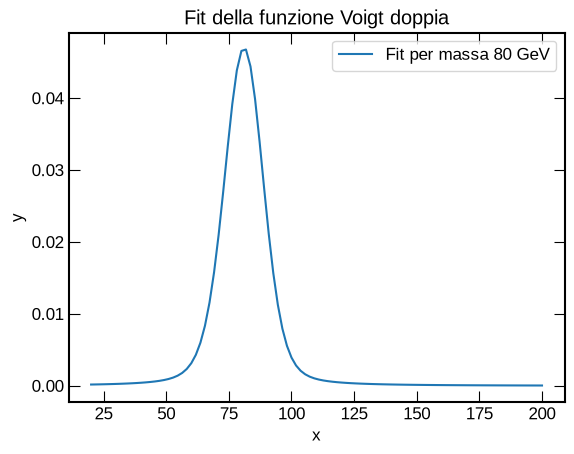

In [16]:
from scipy.special import voigt_profile

def voigt2(x, norm, mu, sigma, gamma, norm2, mu2, sigma2, gamma2):
    return voigt_profile(x-mu, sigma, gamma) * norm + norm2*voigt_profile(x-mu2, sigma2, gamma2)

x_prova = np.linspace(20, 200, 100)
y_prova = voigt2(x_prova, fit_parameters_80["norm"], fit_parameters_80["mu"], fit_parameters_80["sigma"], fit_parameters_80["gamma"], fit_parameters_80["norm2"], fit_parameters_80["mu2"], fit_parameters_80["sigma2"], fit_parameters_80["gamma2"])

plt.figure()
plt.plot(x_prova, y_prova, label='Fit per massa 80 GeV')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fit della funzione Voigt doppia')
plt.legend()
plt.show()



In [17]:
#Ora scriviamo qui tutti i valori dei chi2 ridotto per tutte le masse e tutte le funzioni

chi2_ridotti_gauss = {"MH25":64.5 ,"MH50":181.2, "MH75":82.8, "MH100":  73.4, "MH125": 52.1, "MH150":92.7, "MH175": 56.9, "MH200":  54.4}
chi2_ridotti_cb = {"MH25":48.9, "MH50":125.2252, "MH75":13.4, "MH100": 23.5, "MH125": 17.7, "MH150": 15.3, "MH175": 10.8, "MH200":  3.8}
chi2_ridotti_voigt = {"MH25":54.1, "MH50":223.4, "MH75":40.6, "MH100": 19.9, "MH125": 13.1, "MH150": 17.0, "MH175": 30.3, "MH200": 43.4}
chi2_ridotti_voigt2 = {"MH25":16.7, "MH50":181.2, "MH75":13.4, "MH100":2.5, "MH125": 1.5, "MH150": 1.1, "MH175": 2.5, "MH200": 2.1}